# Fuel the Data _ Data Merge

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [22]:
os.chdir("/Users/soobin/Documents/fuelthedata")

poverty = pd.read_excel("data/PovertyReport.xlsx", skiprows=5)
unemployment = pd.read_excel("data/UnemploymentReport.xlsx", skiprows=3)

In [23]:
print(unemployment.head())
print(unemployment.columns)

  Unnamed: 0   FIPS         Name  2015  2016  2017  2018  2019  2020  2021  \
0        NaN  1000.0     Alabama   6.1   5.9   4.5   3.9   3.2   6.4   3.4   
1        NaN  2000.0      Alaska   6.3   6.6   6.5   6.0   5.6   8.3   6.4   
2        NaN  4000.0     Arizona   6.1   5.5   5.0   4.8   4.8   7.8   5.1   
3        NaN  5000.0    Arkansas   5.0   4.0   3.7   3.7   3.5   6.2   4.0   
4        NaN  6000.0  California   6.3   5.5   4.8   4.2   4.1  10.1   7.3   

   2022  2023 Median Household Income (2022)  
0   2.5   2.5                        $59,703  
1   4.2   4.2                        $88,072  
2   3.8   3.9                        $74,355  
3   3.2   3.3                        $55,505  
4   4.3   4.8                        $91,517  
Index([                    'Unnamed: 0',                          'FIPS ',
                                 'Name',                           '2015',
                                   2016,                             2017,
                        

In [24]:
print(poverty.head())
print(poverty.columns)

         Name  Unnamed: 1  Unnamed: 2  Unnamed: 3  Percent  Unnamed: 5  \
0     Alabama         NaN         NaN         NaN     15.7         NaN   
1      Alaska         NaN         NaN         NaN     10.5         NaN   
2     Arizona         NaN         NaN         NaN     12.6         NaN   
3    Arkansas         NaN         NaN         NaN     15.4         NaN   
4  California         NaN         NaN         NaN     12.0         NaN   

   Lower Bound  Upper Bound  Percent.1  Lower Bound.1  Upper Bound.1  
0         15.3         16.1       21.3           20.5           22.1  
1          9.9         11.1       12.5           11.4           13.6  
2         12.3         12.9       15.8           15.1           16.5  
3         15.0         15.8       20.2           19.1           21.3  
4         11.9         12.1       15.0           14.6           15.4  
Index(['Name', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Percent',
       'Unnamed: 5', 'Lower Bound', 'Upper Bound', 'Percent.1

In [25]:
poverty = poverty[['Name', 'Percent']]
poverty = poverty.rename(columns={
    'Name': 'State',
    'Percent': 'Poverty Rate'
})

In [26]:
unemployment = unemployment[['Name', '2023']]
unemployment = unemployment.rename(columns={
    'Name': 'State',
    '2023': 'Unemployment Rate'
})

In [27]:
print(poverty.head())
print(unemployment.head())

        State  Poverty Rate
0     Alabama          15.7
1      Alaska          10.5
2     Arizona          12.6
3    Arkansas          15.4
4  California          12.0
        State  Unemployment Rate
0     Alabama                2.5
1      Alaska                4.2
2     Arizona                3.9
3    Arkansas                3.3
4  California                4.8


In [28]:
merged = poverty.merge(unemployment, on="State")

In [29]:
print(merged.head())
print(merged.shape)

        State  Poverty Rate  Unemployment Rate
0     Alabama          15.7                2.5
1      Alaska          10.5                4.2
2     Arizona          12.6                3.9
3    Arkansas          15.4                3.3
4  California          12.0                4.8
(52, 3)


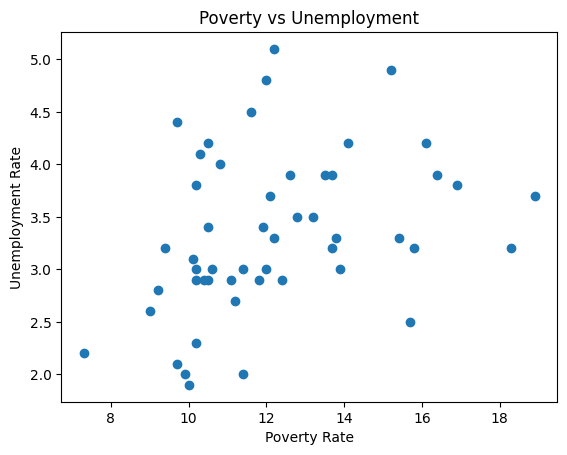

In [30]:
plt.scatter(merged['Poverty Rate'], merged['Unemployment Rate'])
plt.xlabel('Poverty Rate')
plt.ylabel('Unemployment Rate')
plt.title('Poverty vs Unemployment')
plt.show()

The scatter plot shows the relationship between poverty rate and unemployment rate across states. Overall, there does not appear to be a strong linear relationship between the two variables. While some states with higher poverty rates also have higher unemployment, the data points are widely scattered. This suggests that poverty and unemployment are not strongly correlated in this dataset.

In [32]:
corr = merged.corr(numeric_only=True)
print(corr)

                   Poverty Rate  Unemployment Rate
Poverty Rate           1.000000           0.345564
Unemployment Rate      0.345564           1.000000


The correlation between poverty rate and unemployment rate is approximately 0.35, indicating a weak to moderate positive relationship. This suggests that states with higher poverty rates tend to have slightly higher unemployment rates, although the relationship is not very strong. This pattern is consistent with the scatter plot, where the data points show some upward trend but remain widely dispersed.